# Avance 2 – Estrategia Iron Condor sobre XLE
**Materia:** Simulación de Procesos Financieros  
**Profesor:** Mtro. Alan Omar Topete Salazar  
**Integrantes:** Gonzalo Cano Padilla, Nicolás Martínez Gutiérrez  
**Institución:** ITESO – Ingeniería Financiera

---
## Sección 1 – Parámetros y datos reales

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

### 1.1 Descarga de precios históricos de XLE

In [2]:
xle = yf.download('XLE', period='1y', auto_adjust=True)
precios = xle['Close'].squeeze().dropna()
print(f'Registros descargados: {len(precios)}')
print(f'Período: {precios.index[0].date()} → {precios.index[-1].date()}')
precios.tail()

[*********************100%***********************]  1 of 1 completed

Registros descargados: 251
Período: 2025-04-29 → 2026-04-28


Date
2026-04-22    56.540001
2026-04-23    56.980000
2026-04-24    56.869999
2026-04-27    56.770000
2026-04-28    57.709999
Name: XLE, dtype: float64

### 1.2 Precio actual del subyacente (S)

In [3]:
S = float(precios.iloc[-1])
print(f'Precio actual de XLE (S): USD {S:.2f}')

Precio actual de XLE (S): USD 57.71


### 1.3 Volatilidad histórica anualizada

In [4]:
# Retornos diarios
retornos = precios.pct_change().dropna()

# Volatilidad diaria y anualizada
vol_diaria = retornos.std()
sigma = float(vol_diaria * np.sqrt(252))

print(f'Volatilidad diaria:      {vol_diaria:.4f} ({vol_diaria*100:.2f}%)')
print(f'Volatilidad anualizada:  {sigma:.4f} ({sigma*100:.2f}%)')

Volatilidad diaria:      0.0124 (1.24%)
Volatilidad anualizada:  0.1970 (19.70%)


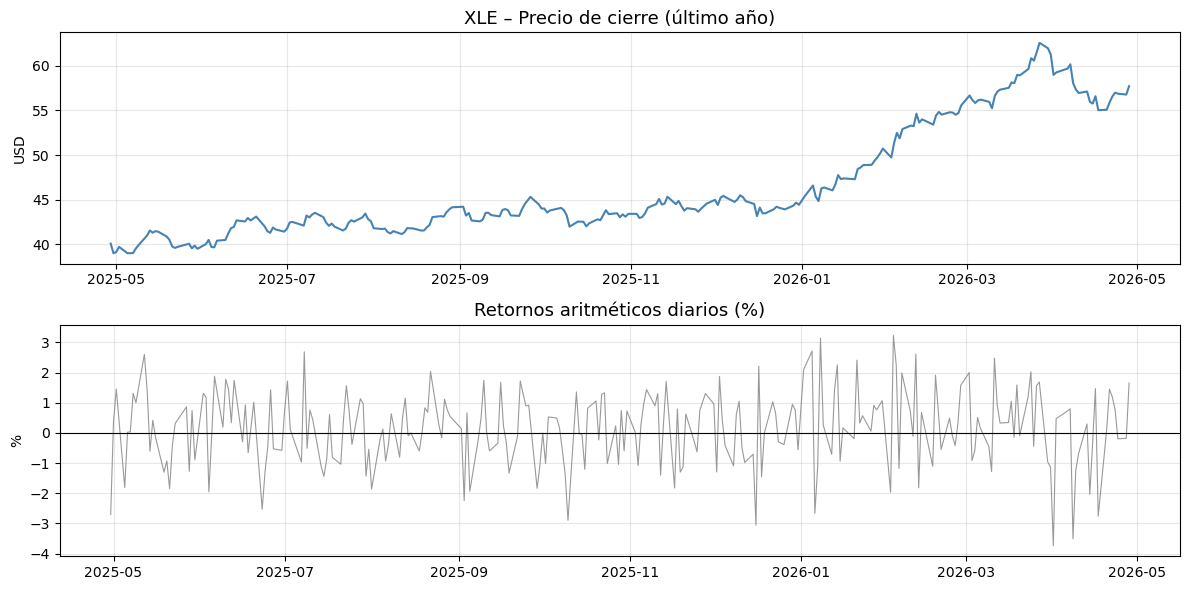

In [5]:
# Gráfica de precios y retornos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

ax1.plot(precios.index, precios.values, color='steelblue', linewidth=1.5)
ax1.set_title('XLE – Precio de cierre (último año)', fontsize=13)
ax1.set_ylabel('USD')
ax1.grid(True, alpha=0.3)

ax2.plot(retornos.index, retornos.values * 100, color='gray', linewidth=0.8, alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Retornos aritméticos diarios (%)', fontsize=13)
ax2.set_ylabel('%')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.4 Tasa libre de riesgo

In [6]:
# T-Bill a 3 meses desde yfinance (^IRX cotiza en %)
try:
    irx = yf.download('^IRX', period='5d', auto_adjust=True)
    r = float(irx['Close'].dropna().iloc[-1]) / 100
    print(f'Tasa libre de riesgo (^IRX, T-Bill 3M): {r*100:.3f}%')
except Exception:
    r = 0.043  # fallback: ~4.3% anual Q1-2026
    print(f'Tasa libre de riesgo (fija, referencial Fed Funds): {r*100:.2f}%')

[*********************100%***********************]  1 of 1 completed

Tasa libre de riesgo (^IRX, T-Bill 3M): 3.590%


### 1.5 Tiempo al vencimiento (T)

In [7]:
# Vencimiento a 45 días calendario
dias_al_vencimiento = 45
T = dias_al_vencimiento / 365
print(f'Días al vencimiento: {dias_al_vencimiento}')
print(f'T (en años):         {T:.4f}')

Días al vencimiento: 45
T (en años):         0.1233


### 1.6 Definición de los 4 strikes del Iron Condor

Los strikes se calculan como porcentajes sobre el precio actual (S), aproximados a múltiplos de USD 1 para reflejar strikes estándar de opciones sobre ETFs.

| Opción | Tipo | Strike | Posición | Distancia de S |
|--------|------|--------|----------|----------------|
| Long Put | put | K1 | comprada | −10% |
| Short Put | put | K2 | vendida | −5% |
| Short Call | call | K3 | vendida | +5% |
| Long Call | call | K4 | comprada | +10% |

In [8]:
# Strikes redondeados a múltiplos de 1 USD
K1 = round(S * 0.90)
K2 = round(S * 0.95)
K3 = round(S * 1.05)
K4 = round(S * 1.10)

print('Iron Condor – Estructura de strikes')
print('=' * 40)
print(f'Precio actual S:   USD {S:.2f}')
print(f'K1 (Long Put):     USD {K1:.0f}  ({(K1/S-1)*100:.1f}% de S)')
print(f'K2 (Short Put):    USD {K2:.0f}  ({(K2/S-1)*100:.1f}% de S)')
print(f'K3 (Short Call):   USD {K3:.0f}  ({(K3/S-1)*100:+.1f}% de S)')
print(f'K4 (Long Call):    USD {K4:.0f}  ({(K4/S-1)*100:+.1f}% de S)')
print(f'T al vencimiento:  {dias_al_vencimiento} días ({T:.4f} años)')
print(f'Volatilidad (σ):   {sigma*100:.2f}%')
print(f'Tasa libre (r):    {r*100:.3f}%')

Iron Condor – Estructura de strikes
Precio actual S:   USD 57.71
K1 (Long Put):     USD 52  (-9.9% de S)
K2 (Short Put):    USD 55  (-4.7% de S)
K3 (Short Call):   USD 61  (+5.7% de S)
K4 (Long Call):    USD 63  (+9.2% de S)
T al vencimiento:  45 días (0.1233 años)
Volatilidad (σ):   19.70%
Tasa libre (r):    3.590%


---
## Sección 2 – Valuación con Black-Scholes

In [9]:
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, tipo):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if tipo == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

In [10]:
# Precios teóricos de las 4 opciones
p_K1 = black_scholes(S, K1, T, r, sigma, 'put')   # Long Put
p_K2 = black_scholes(S, K2, T, r, sigma, 'put')   # Short Put
p_K3 = black_scholes(S, K3, T, r, sigma, 'call')  # Short Call
p_K4 = black_scholes(S, K4, T, r, sigma, 'call')  # Long Call

# Prima neta recibida (crédito neto del Iron Condor)
prima_neta = (p_K2 - p_K1) + (p_K3 - p_K4)

print('Valuación Black-Scholes – Iron Condor')
print('=' * 45)
print(f'Long Put   K1={K1}: USD {p_K1:.4f}  (pagamos)')
print(f'Short Put  K2={K2}: USD {p_K2:.4f}  (cobramos)')
print(f'Short Call K3={K3}: USD {p_K3:.4f}  (cobramos)')
print(f'Long Call  K4={K4}: USD {p_K4:.4f}  (pagamos)')
print('-' * 45)
print(f'Bull Put Spread   (K2−K1): USD {p_K2 - p_K1:.4f}')
print(f'Bear Call Spread  (K3−K4): USD {p_K3 - p_K4:.4f}')
print(f'Prima neta recibida:        USD {prima_neta:.4f}')

Valuación Black-Scholes – Iron Condor
Long Put   K1=52: USD 0.0943  (pagamos)
Short Put  K2=55: USD 0.5019  (cobramos)
Short Call K3=61: USD 0.5488  (cobramos)
Long Call  K4=63: USD 0.2316  (pagamos)
---------------------------------------------
Bull Put Spread   (K2−K1): USD 0.4076
Bear Call Spread  (K3−K4): USD 0.3172
Prima neta recibida:        USD 0.7248


---
## Sección 3 – Payoff de la estrategia al vencimiento

In [11]:
# Rango de precios finales del subyacente al vencimiento
S_T = np.linspace(K1 * 0.85, K4 * 1.15, 500)

# Payoff al vencimiento (incluyendo prima neta cobrada)
payoff = (prima_neta
          - np.maximum(0, S_T - K4)   # Long Call
          + np.maximum(0, S_T - K3)   # Short Call
          + np.maximum(0, K2 - S_T)   # Short Put
          - np.maximum(0, K1 - S_T))  # Long Put

ganancia_max = prima_neta
perdida_max  = (K2 - K1) - prima_neta  # ancho del spread - prima

# Breakeven points
be_bajo = K2 - prima_neta
be_alto = K3 + prima_neta

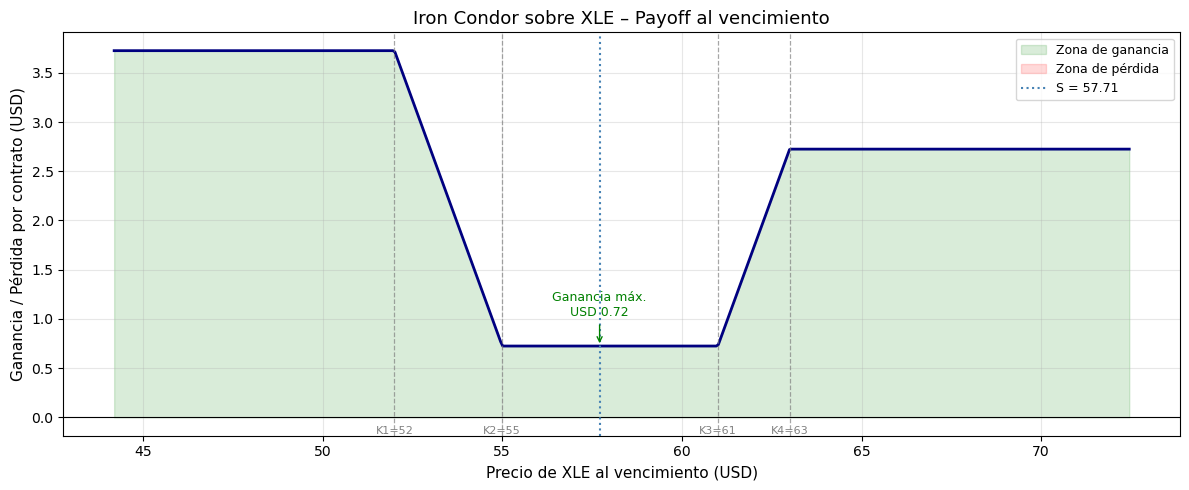

Breakeven inferior: USD 54.28
Breakeven superior: USD 61.72
Ganancia máxima:    USD 0.7248  (prima neta cobrada)
Pérdida máxima:     USD 2.2752  (ancho spread − prima)


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

# Zona de ganancia (entre breakevens)
ax.fill_between(S_T, payoff, 0,
                where=(payoff > 0), color='green', alpha=0.15, label='Zona de ganancia')
ax.fill_between(S_T, payoff, 0,
                where=(payoff < 0), color='red', alpha=0.15, label='Zona de pérdida')

ax.plot(S_T, payoff, color='navy', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8)

# Strikes verticales
for k, lbl in [(K1, f'K1={K1}'), (K2, f'K2={K2}'),
               (K3, f'K3={K3}'), (K4, f'K4={K4}')]:
    ax.axvline(k, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
    ax.text(k, ax.get_ylim()[0] * 0.92, lbl, ha='center', fontsize=8, color='gray')

# Precio actual
ax.axvline(S, color='steelblue', linestyle=':', linewidth=1.5, label=f'S = {S:.2f}')

# Anotaciones
ax.annotate(f'Ganancia máx.\nUSD {ganancia_max:.2f}',
            xy=(S, ganancia_max), xytext=(S, ganancia_max + 0.3),
            ha='center', fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

ax.annotate(f'Pérdida máx.\n−USD {perdida_max:.2f}',
            xy=(K1 * 0.92, -perdida_max), xytext=(K1 * 0.92, -perdida_max - 0.3),
            ha='center', fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('Precio de XLE al vencimiento (USD)', fontsize=11)
ax.set_ylabel('Ganancia / Pérdida por contrato (USD)', fontsize=11)
ax.set_title('Iron Condor sobre XLE – Payoff al vencimiento', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Breakeven inferior: USD {be_bajo:.2f}')
print(f'Breakeven superior: USD {be_alto:.2f}')
print(f'Ganancia máxima:    USD {ganancia_max:.4f}  (prima neta cobrada)')
print(f'Pérdida máxima:     USD {perdida_max:.4f}  (ancho spread − prima)')

La gráfica muestra el perfil de ganancia/pérdida del Iron Condor al vencimiento. La zona verde (entre los breakevens) es donde XLE debe cerrar para que la estrategia sea rentable. La ganancia máxima es la prima neta cobrada al inicio; la pérdida máxima está acotada por el ancho de los spreads menos dicha prima.

---
## Sección 5 – Análisis de Griegas

In [13]:
def griegas_bs(S, K, T, r, sigma, tipo):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    phi = norm.pdf(d1)

    gamma = phi / (S * sigma * np.sqrt(T))
    vega  = S * phi * np.sqrt(T) / 100  # por 1% de cambio en sigma

    if tipo == 'call':
        delta = norm.cdf(d1)
        theta = (-(S * phi * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
        rho   = K * T * np.exp(-r * T) * norm.cdf(d2) / 100
    else:
        delta = norm.cdf(d1) - 1
        theta = (-(S * phi * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
        rho   = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100

    return {'delta': delta, 'gamma': gamma, 'theta': theta, 'vega': vega, 'rho': rho}

In [14]:
# Griegas individuales de cada pata
g_K1 = griegas_bs(S, K1, T, r, sigma, 'put')   # Long Put  (+1)
g_K2 = griegas_bs(S, K2, T, r, sigma, 'put')   # Short Put (−1)
g_K3 = griegas_bs(S, K3, T, r, sigma, 'call')  # Short Call(−1)
g_K4 = griegas_bs(S, K4, T, r, sigma, 'call')  # Long Call (+1)

# Posiciones: Long Put +1, Short Put -1, Short Call -1, Long Call +1
posiciones = [+1, -1, -1, +1]
griegas_opciones = [g_K1, g_K2, g_K3, g_K4]

# Griegas netas del Iron Condor
griegas_netas = {}
for griega in ['delta', 'gamma', 'theta', 'vega', 'rho']:
    griegas_netas[griega] = sum(pos * g[griega]
                                for pos, g in zip(posiciones, griegas_opciones))

# Tabla resumen
nombres = ['Long Put K1', 'Short Put K2', 'Short Call K3', 'Long Call K4']
strikes = [K1, K2, K3, K4]
signos  = ['+1', '−1', '−1', '+1']

df_griegas = pd.DataFrame(
    {
        'Opción':    nombres,
        'Strike':   strikes,
        'Posición': signos,
        'Delta':    [g['delta'] for g in griegas_opciones],
        'Gamma':    [g['gamma'] for g in griegas_opciones],
        'Theta':    [g['theta'] for g in griegas_opciones],
        'Vega':     [g['vega']  for g in griegas_opciones],
        'Rho':      [g['rho']   for g in griegas_opciones],
    }
)

# Fila de netas
fila_neta = pd.DataFrame([{
    'Opción': 'NETO Iron Condor', 'Strike': '—', 'Posición': '—',
    **{k: griegas_netas[k] for k in ['delta', 'gamma', 'theta', 'vega', 'rho']}
}])
fila_neta.columns = df_griegas.columns

df_griegas = pd.concat([df_griegas, fila_neta], ignore_index=True)

pd.set_option('display.float_format', '{:.6f}'.format)
df_griegas

,Opción,Strike,Posición,Delta,Gamma,Theta,Vega,Rho
0,Long Put K1,52,+1,-0.054302,0.027582,-0.004568,0.022315,-0.003980
1,Short Put K2,55,−1,-0.213663,0.072918,-0.011653,0.058993,-0.015821
2,Short Call K3,61,−1,0.241083,0.078053,-0.015139,0.063148,0.016476
3,Long Call K4,63,+1,0.121176,0.050448,-0.009600,0.040814,0.008336
4,NETO Iron Condor,—,—,0.039455,-0.072941,0.012624,-0.059012,0.003701


In [15]:
print('Griegas netas del Iron Condor')
print('=' * 40)
for g, v in griegas_netas.items():
    print(f'{g.capitalize():8s}: {v:+.6f}')

Griegas netas del Iron Condor
Delta   : +0.039455
Gamma   : -0.072941
Theta   : +0.012624
Vega    : -0.059012
Rho     : +0.003701


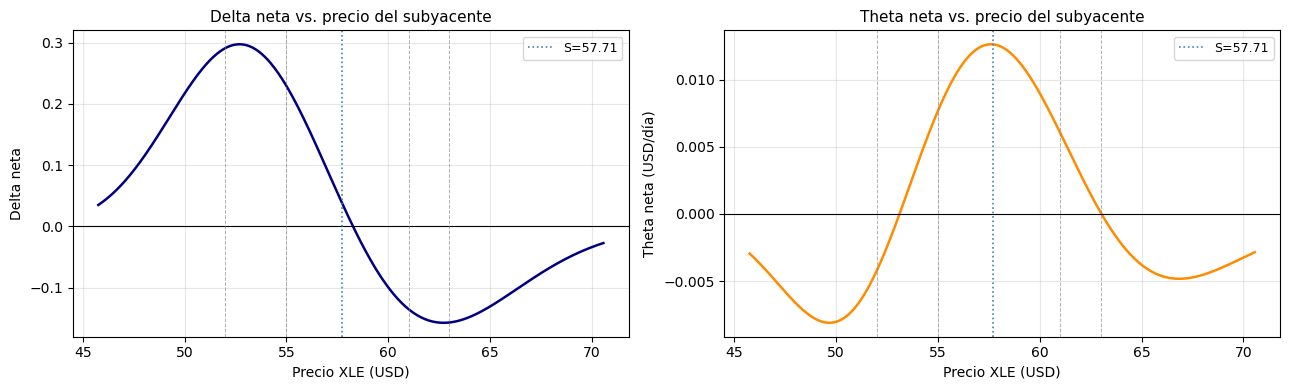

In [16]:
# Gráfica de Delta y Theta netas en función del precio del subyacente
S_rango = np.linspace(K1 * 0.88, K4 * 1.12, 400)

delta_neta = []
theta_neta = []

for s in S_rango:
    gk1 = griegas_bs(s, K1, T, r, sigma, 'put')
    gk2 = griegas_bs(s, K2, T, r, sigma, 'put')
    gk3 = griegas_bs(s, K3, T, r, sigma, 'call')
    gk4 = griegas_bs(s, K4, T, r, sigma, 'call')
    delta_neta.append(+gk1['delta'] - gk2['delta'] - gk3['delta'] + gk4['delta'])
    theta_neta.append(+gk1['theta'] - gk2['theta'] - gk3['theta'] + gk4['theta'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(S_rango, delta_neta, color='navy', linewidth=1.8)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(S, color='steelblue', linestyle=':', linewidth=1.2, label=f'S={S:.2f}')
for k in [K1, K2, K3, K4]:
    ax1.axvline(k, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
ax1.set_title('Delta neta vs. precio del subyacente', fontsize=11)
ax1.set_xlabel('Precio XLE (USD)')
ax1.set_ylabel('Delta neta')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(S_rango, theta_neta, color='darkorange', linewidth=1.8)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(S, color='steelblue', linestyle=':', linewidth=1.2, label=f'S={S:.2f}')
for k in [K1, K2, K3, K4]:
    ax2.axvline(k, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
ax2.set_title('Theta neta vs. precio del subyacente', fontsize=11)
ax2.set_xlabel('Precio XLE (USD)')
ax2.set_ylabel('Theta neta (USD/día)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación de las griegas netas:**

- **Delta ≈ 0:** la estrategia es aproximadamente neutral al precio cuando XLE cotiza dentro del rango. Se vuelve negativa si XLE sube y positiva si baja, lo cual refleja el riesgo direccional en los extremos.
- **Gamma < 0:** el Iron Condor es gamma negativa. La posición se deteriora si hay movimientos grandes en cualquier dirección.
- **Theta > 0:** el paso del tiempo juega a favor de la estrategia. Cada día que XLE se mantiene en rango, la estrategia gana valor.
- **Vega < 0:** una caída en la volatilidad implícita beneficia a la estrategia; un aumento la perjudica. Esto es consistente con el contexto de mercado justificado en el Avance 1.

---
## Resumen de resultados

In [17]:
from IPython.display import Markdown

resumen = f"""
### Parámetros de mercado (XLE, {precios.index[-1].date()})

| Parámetro | Valor |
|-----------|-------|
| Precio actual S | USD {S:.2f} |
| Volatilidad histórica anualizada (σ) | {sigma*100:.2f}% |
| Tasa libre de riesgo (r) | {r*100:.3f}% |
| Días al vencimiento | {dias_al_vencimiento} días ({T:.4f} años) |

---

### Estructura del Iron Condor

| Pata | Tipo | Strike | Posición | Precio BS |
|------|------|--------|----------|-----------|
| Long Put | put | USD {K1:.0f} | comprada | USD {p_K1:.4f} |
| Short Put | put | USD {K2:.0f} | vendida | USD {p_K2:.4f} |
| Short Call | call | USD {K3:.0f} | vendida | USD {p_K3:.4f} |
| Long Call | call | USD {K4:.0f} | comprada | USD {p_K4:.4f} |

---

### Métricas de la estrategia

| Métrica | Valor |
|---------|-------|
| Bull Put Spread (K2 − K1) | USD {p_K2 - p_K1:.4f} |
| Bear Call Spread (K3 − K4) | USD {p_K3 - p_K4:.4f} |
| **Prima neta recibida** | **USD {prima_neta:.4f}** |
| Breakeven inferior | USD {be_bajo:.2f} |
| Breakeven superior | USD {be_alto:.2f} |
| **Ganancia máxima** | **USD {ganancia_max:.4f}** (si XLE cierra entre K2 y K3) |
| **Pérdida máxima** | **USD {perdida_max:.4f}** (si XLE cierra por debajo de K1 o por encima de K4) |

---

### Griegas netas del Iron Condor

| Griega | Valor neto | Interpretación |
|--------|-----------|----------------|
| Delta | {griegas_netas['delta']:+.6f} | Estrategia prácticamente neutral al precio |
| Gamma | {griegas_netas['gamma']:+.6f} | Gamma negativa: movimientos grandes perjudican |
| Theta | {griegas_netas['theta']:+.6f} USD/día | El paso del tiempo beneficia la estrategia |
| Vega | {griegas_netas['vega']:+.6f} USD/1%σ | Una caída de volatilidad favorece la posición |
| Rho | {griegas_netas['rho']:+.6f} USD/1%r | Baja sensibilidad a cambios en tasa libre de riesgo |
"""

display(Markdown(resumen))


### Parámetros de mercado (XLE, 2026-04-28)

| Parámetro | Valor |
|-----------|-------|
| Precio actual S | USD 57.71 |
| Volatilidad histórica anualizada (σ) | 19.70% |
| Tasa libre de riesgo (r) | 3.590% |
| Días al vencimiento | 45 días (0.1233 años) |

---

### Estructura del Iron Condor

| Pata | Tipo | Strike | Posición | Precio BS |
|------|------|--------|----------|-----------|
| Long Put | put | USD 52 | comprada | USD 0.0943 |
| Short Put | put | USD 55 | vendida | USD 0.5019 |
| Short Call | call | USD 61 | vendida | USD 0.5488 |
| Long Call | call | USD 63 | comprada | USD 0.2316 |

---

### Métricas de la estrategia

| Métrica | Valor |
|---------|-------|
| Bull Put Spread (K2 − K1) | USD 0.4076 |
| Bear Call Spread (K3 − K4) | USD 0.3172 |
| **Prima neta recibida** | **USD 0.7248** |
| Breakeven inferior | USD 54.28 |
| Breakeven superior | USD 61.72 |
| **Ganancia máxima** | **USD 0.7248** (si XLE cierra entre K2 y K3) |
| **Pérdida máxima** | **USD 2.2752** (si XLE cierra por debajo de K1 o por encima de K4) |

---

### Griegas netas del Iron Condor

| Griega | Valor neto | Interpretación |
|--------|-----------|----------------|
| Delta | +0.039455 | Estrategia prácticamente neutral al precio |
| Gamma | -0.072941 | Gamma negativa: movimientos grandes perjudican |
| Theta | +0.012624 USD/día | El paso del tiempo beneficia la estrategia |
| Vega | -0.059012 USD/1%σ | Una caída de volatilidad favorece la posición |
| Rho | +0.003701 USD/1%r | Baja sensibilidad a cambios en tasa libre de riesgo |
